Autor:  
Manuel Eugenio Morocho Cayamcela, PhD

# **Tree-Based Models** 

Dataset: **Wine dataset**

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# ML models
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

# Reproducibility
np.random.seed(42)

### **Step 1:** Load Dataset (Wine)

Think of this as a **real-world classification problem**:
We want to classify wine types based on chemical features.

More interesting than Iris → more features, more complexity.


In [2]:
# Load dataset
data = load_wine()
X = data.data
y = data.target

# Visualize the data in a pandas DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Train-test split (IMPORTANT to detect overfitting)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (124, 13)
Test size: (54, 13)


### **Step 2:** Decision Tree (Simple but might overfit)

**Analogy:** A single student memorizing answers instead of understanding.

**Problem:** Overfitting (great on training, bad on new data)


In [4]:
# Train a decision tree WITHOUT restrictions
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Predictions
train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))


Train accuracy: 1.0
Test accuracy: 0.9629629629629629


In [5]:
# Train trees with different max_depth values to see the effect on overfitting
depths = [1,2,3,5,10,None]

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d)
    tree.fit(X_train, y_train)

    train = tree.score(X_train, y_train)
    test = tree.score(X_test, y_test)

    print(f"Depth {d}: Train={train:.3f}, Test={test:.3f}")

Depth 1: Train=0.661, Test=0.611
Depth 2: Train=0.944, Test=0.852
Depth 3: Train=0.992, Test=0.944
Depth 5: Train=1.000, Test=0.944
Depth 10: Train=1.000, Test=0.944
Depth None: Train=1.000, Test=0.944


**Observation**
- Training accuracy is usually VERY HIGH (even 1.0)
- Test accuracy is lower → this is OVERFITTING  

The model memorizes instead of generalizing.

In [6]:
# Extract rules

from sklearn.tree import export_text

rules = export_text(tree, feature_names=data.feature_names)
print(rules)

|--- color_intensity <= 3.82
|   |--- od280/od315_of_diluted_wines <= 3.82
|   |   |--- ash <= 3.07
|   |   |   |--- class: 1
|   |   |--- ash >  3.07
|   |   |   |--- class: 0
|   |--- od280/od315_of_diluted_wines >  3.82
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.40
|   |   |--- class: 2
|   |--- flavanoids >  1.40
|   |   |--- proline <= 724.50
|   |   |   |--- alcohol <= 13.14
|   |   |   |   |--- class: 1
|   |   |   |--- alcohol >  13.14
|   |   |   |   |--- class: 0
|   |   |--- proline >  724.50
|   |   |   |--- class: 0



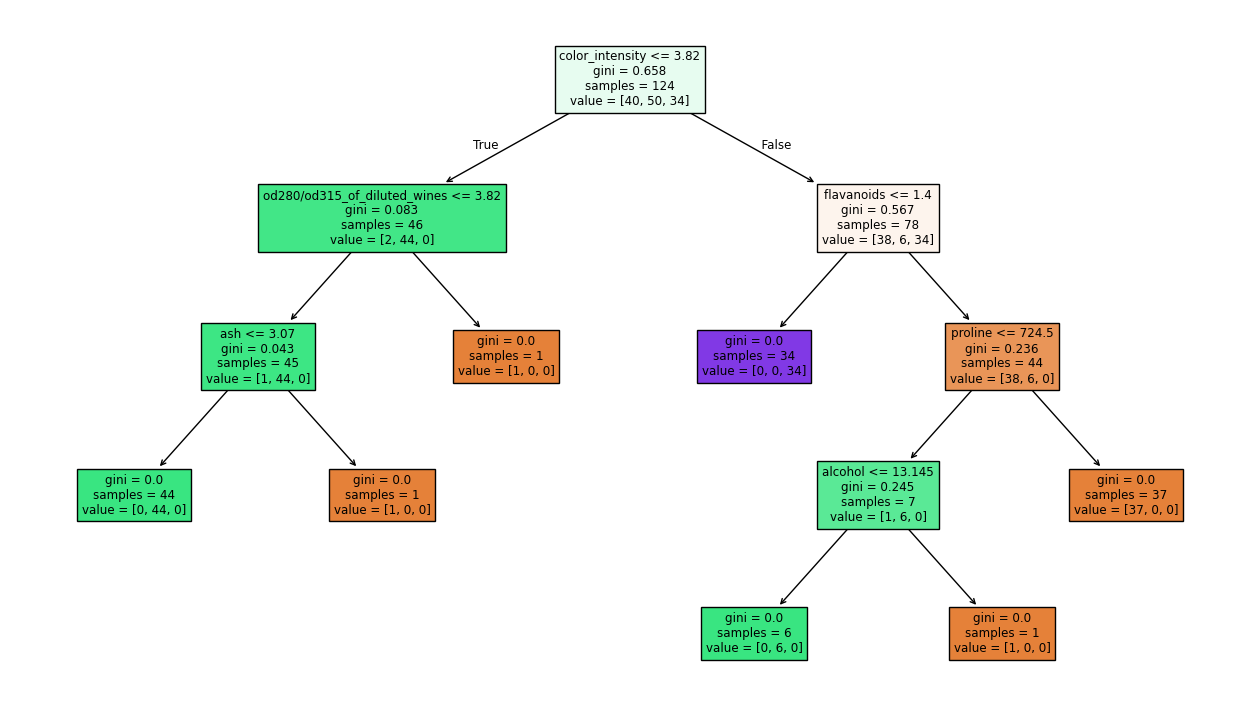

In [9]:
# Plot the tree with feature names
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 9))
plot_tree(tree, filled=True, feature_names=data.feature_names)
plt.show()

In [ ]:
# Feature importance

import pandas as pd

importance = pd.Series(tree.feature_importances_, index=data.feature_names)
importance.sort_values(ascending=False)

Importances of *0* indicates that the tree never used those features to slit the decision.

In [ ]:
# Shap to explain predictions
import shap
explainer = shap.TreeExplainer(tree)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=data.feature_names, plot_type="bar")

### **Step 3:** Bagging (Fixing Overfitting)

**Analogy:** Instead of ONE student, we use MANY students and average their answers.

Idea:
- Train many trees on different samples (the algorithm creates 50 different datasets from `X_train`)  
    **Bootstrap sampling** (for each tree):
    1. It samples with replacement from X_train
    2. Same size as original dataset
    3. Some samples appear multiple times
    4. Some samples are not included
- Combine predictions 
    - **Classification:** majority voting
    - **Regression:** mean

*Reduces **variance***

In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag.fit(X_train, y_train)

train_pred = bag.predict(X_train)
test_pred = bag.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))


**Observation**
- Training accuracy slightly lower
- Test accuracy improves

Less overfitting than a single tree

### **Step 4:** Random Forest (even better)

**Analogy:**
Each student focuses on DIFFERENT parts of the exam.

New idea:
- Random data (like Bagging) + Random features selection on each split

More diversity → better performance  

*Reduces **variance** and **correlation** between trees*

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_features="sqrt" # sqrt is the default for classification, and means that each tree will consider only sqrt(n_features) when looking for the best split. You can try other value, but usually this is a good choice.
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))


**Observation**  
- Usually better generalization
- Strong baseline model in real-world problems


### **Step 5:** Boosting (learning from mistakes)

**Analogy:** A student studies MORE the questions they failed.

Instead of parallel models:
- Models are simpler and sequential
- Each focuses on previous errors

AdaBoost assigns higher weights to misclassified samples, forcing the next tree to focus on them. This way, it creates a sequence of trees that learn from each other, and the final prediction is a weighted average of all trees.

In [ ]:
adb = AdaBoostClassifier( 
    n_estimators=50,
    random_state=42
)

adb.fit(X_train, y_train)

train_pred = adb.predict(X_train)
test_pred = adb.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))


**Observation**
- Can outperform Random Forest
- But:  
  - Sensitive to noise  
  - Needs tuning

More powerful but less robust

Other advanced techniques:  
- Gradient boosting  
- XGBoost  
- LightGBM
- CatBoost

### **Final Comparison**

| Model | Strength | Weakness |
|------|--------|--------|
| Decision Tree | Simple | Overfits |
| Bagging | Reduces variance | Less interpretable |
| Random Forest | Strong & robust | Still complex |
| Boosting | Very powerful | Sensitive |

### **Final Idea**

One tree = memorization  
Many trees = generalization  
Sequential learning = intelligence
